In [1]:
# Importação das bibliotecas bases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Algoritmo Adaline

1) **Batch Gradient Descent**: batch = True
2) **Stochastic Gradient Descent**: batch = False

In [164]:
class Adaline:
    def __init__(self, learning_rate=0.01, epochs=100, precision=0.001, batch=True, seed=None):
        self.weights = None
        self.errors_class = []
        self.errors_ms = []
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.seed = seed
        self.batch = batch
        self.precision = precision

    def activation_function(self, u):
        '''Função de ativação sinal'''
        return np.where(u >= 0, 1, -1)

    def fit(self, X: np.array, y: np.array):
        '''Algoritmo de Treinamento'''
        if self.seed is not None:
            np.random.seed(self.seed)

        n_features, k_samples = X.shape

        # Adiciona bias no vetor de entradas X
        X = np.vstack([np.ones((1, k_samples)), X]) # (n_features + 1, k_samples)

        # vetor de pesos gerados com valores pequenos aleatórios, incluindo o bias
        self.weights = np.random.randn(X.shape[0]) * 0.01 # (1, n_features + 1)

        for epoch in range(self.epochs):
            if self.batch:
                u = np.dot(self.weights.T, X) 
                error = (y - u).flatten()
                self.weights += self.learning_rate * (X @ error.T) / k_samples # dividiu-se pelo número de amostras para tornar o processo mais estável

                
                loss = (error**2).mean() / 2
            else:
                loss = 0
                for k in range(X.shape[1]):
                    x_k = X[:, k]
                    u_k = np.dot(self.weights.T, x_k)

                    error_k = y[0, k] - u_k
                    self.weights += self.learning_rate * error_k * x_k

                    loss = (error_k**2).mean() / 2

                u = self.weights.T @ X

            y_class = self.activation_function(u)
            errors_count = np.sum(y_class != y)
            self.errors_class.append(errors_count / k_samples)

            self.errors_ms.append(loss)

            # Critério de parada
            if epoch > 0 and np.abs(self.errors_ms[-1] - self.errors_ms[-2]) <= self.precision:
                break

        return self.weights, epoch + 1, self.errors_class, self.errors_ms
        
    def predict(self, X:np.array):
        '''Algoritmo de Teste'''
        k_samples = X.shape[1]
        X = np.vstack([np.ones((1, k_samples)), X])
        u = self.weights.T @ X
        return self.activation_function(u)

    def accuracy(self, X:np.array, y:np.array):
        return np.mean(self.predict(X) == y)

#### Gráfico da Evolução dos Erros de Classificação e Erro Quadrático Médio

In [165]:
def plot_error(errors_class, title=None):
    plt.figure(figsize=(10, 6))
    plt.plot(errors_class, marker='o')
    plt.title(title)
    plt.xlabel('Épocas')
    plt.ylabel('Erro de classificação')
    plt.grid(True)
    plt.show()

def plot_error_qm(errors_class, title=None):
    plt.figure(figsize=(10, 6))
    plt.plot(errors_class, marker='o')
    plt.title(title)
    plt.xlabel('Épocas')
    plt.ylabel('Erro Quadrático Médio')
    plt.grid(True)
    plt.show()

### Gráfico da Fronteira de Decisão para dois atributos

In [166]:
def plot_decision_boundary(X, y, model, title=""):
    
    X = np.array(X)
    y = np.array(y).flatten()

    plt.figure(figsize=(10, 6))

    for label in np.unique(y):
        plt.scatter(
            X[0, y == label],
            X[1, y == label],
            label=f"Classe {label}"
        )

    w0, w1, w2 = model.weights # Pesos aprendidos pelo Perceptron com os dados de treinamento

    x1_vals = np.linspace(X[0, :].min(), X[0, :].max(), 100)

    if w2 != 0:
        x2_vals = -(w0 + w1 * x1_vals) / w2
        plt.plot(x1_vals, x2_vals, 'k--', label="Fronteira")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### Dataset 1

* Realizar o treinamento e teste para taxa de aprendizado 0.01, precisão de 0.001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

In [167]:
df_train1 = pd.read_csv('train_dataset1.csv')
X_train1 = df_train1.drop('label', axis=1).values.T # (n_features, k_samples)
y_train1 = df_train1['label'].values.reshape(1, -1) # (, k_samples)

In [168]:
df_test1 = pd.read_csv('test_dataset1.csv')
X_test1 = df_test1.drop('label', axis=1).values.T
y_test1 = df_test1['label'].values.reshape(1, -1)

#### Batch Gradient Descent

##### Treinamento

In [169]:
modelBGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train1, y_train1)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train1, y_train1))

Pesos: [-0.00969543 -0.31831328  0.38039237]
Épocas: 100
Acurácia: 0.9571428571428572


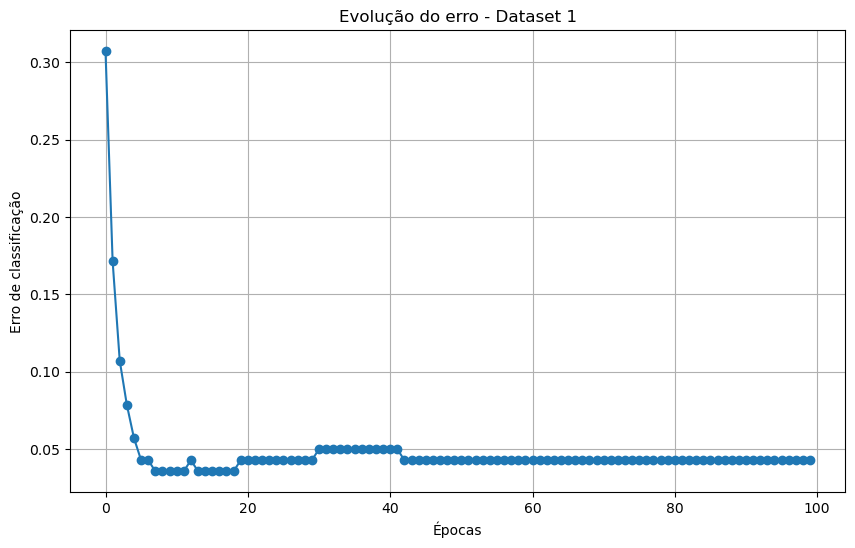

In [170]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 1")

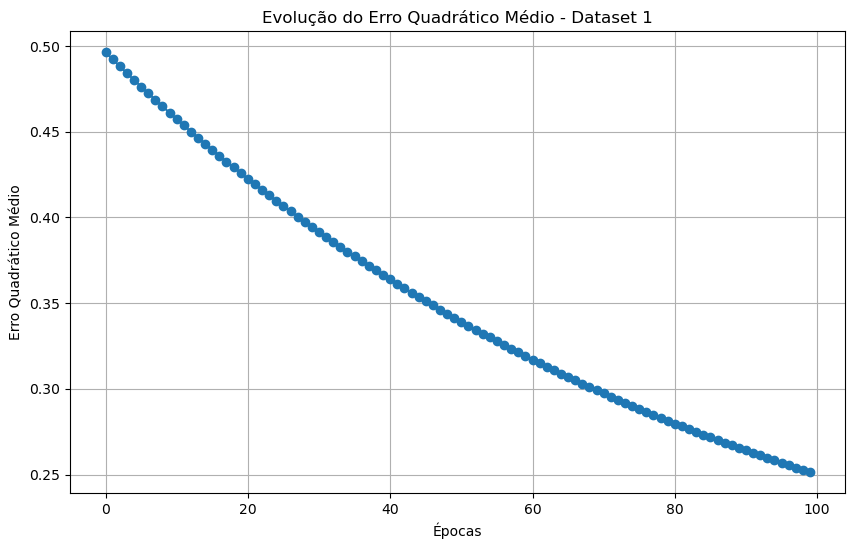

In [171]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 1")

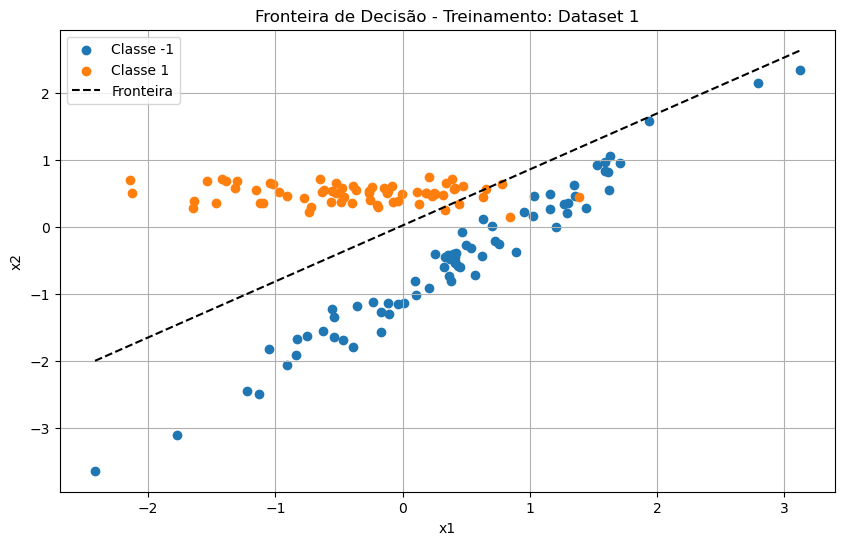

In [172]:
plot_decision_boundary(X_train1, y_train1, modelBGD, title='Fronteira de Decisão - Treinamento: Dataset 1')

##### Teste

In [173]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train1, y_train1))
print("Acurácia Teste:", modelBGD.accuracy(X_test1, y_test1))

Acurácia Treinamento: 0.9571428571428572
Acurácia Teste: 0.9333333333333333


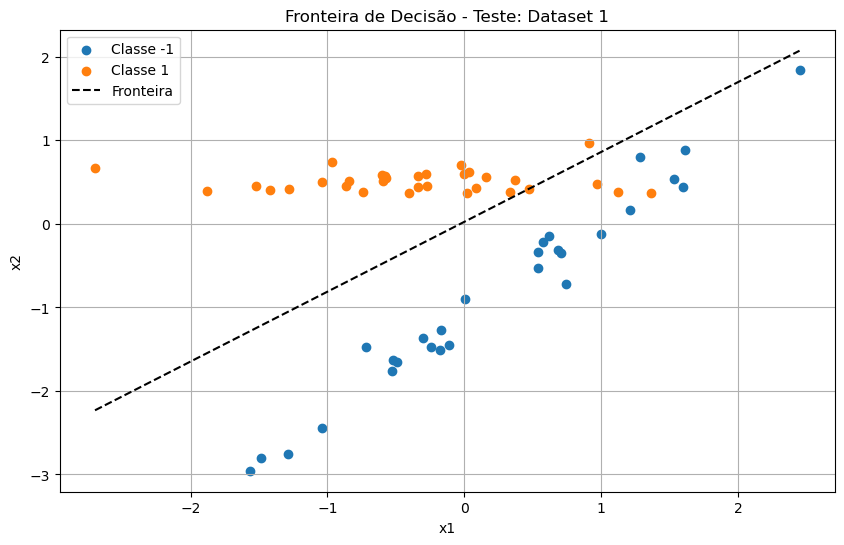

In [174]:
plot_decision_boundary(X_test1, y_test1, modelBGD, title='Fronteira de Decisão - Teste: Dataset 1')

#### Stochastic Gradient Descent

##### Treinamento

In [175]:
modelSGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train1, y_train1)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train1, y_train1))

Pesos: [ 0.01910158 -0.74234857  0.83951449]
Épocas: 5
Acurácia: 0.9571428571428572


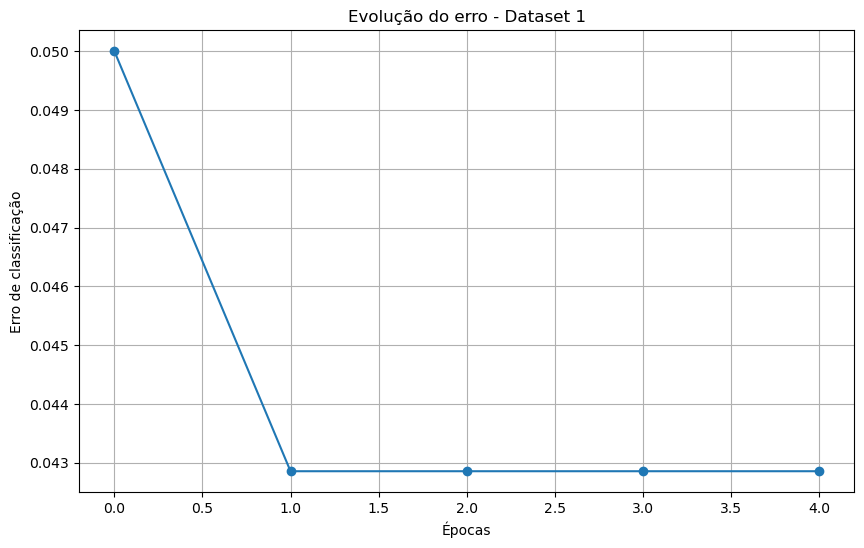

In [176]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 1")

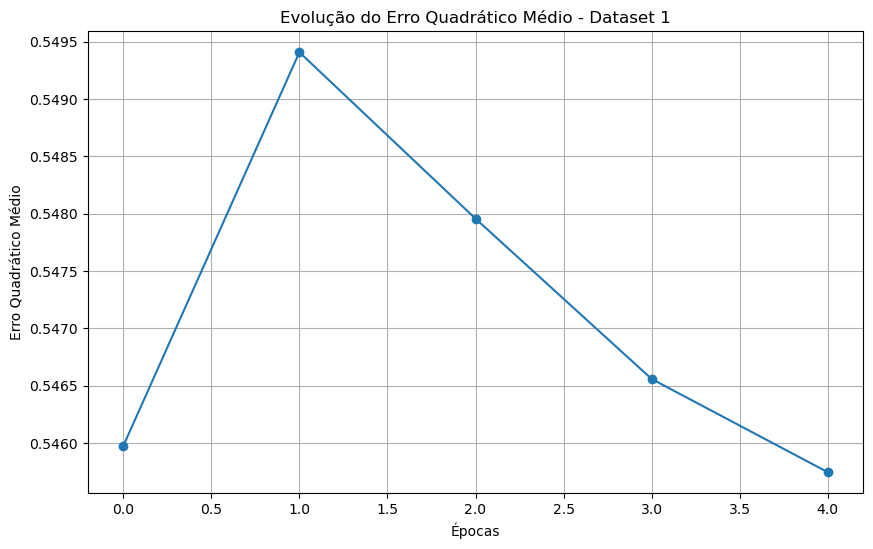

In [177]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 1")

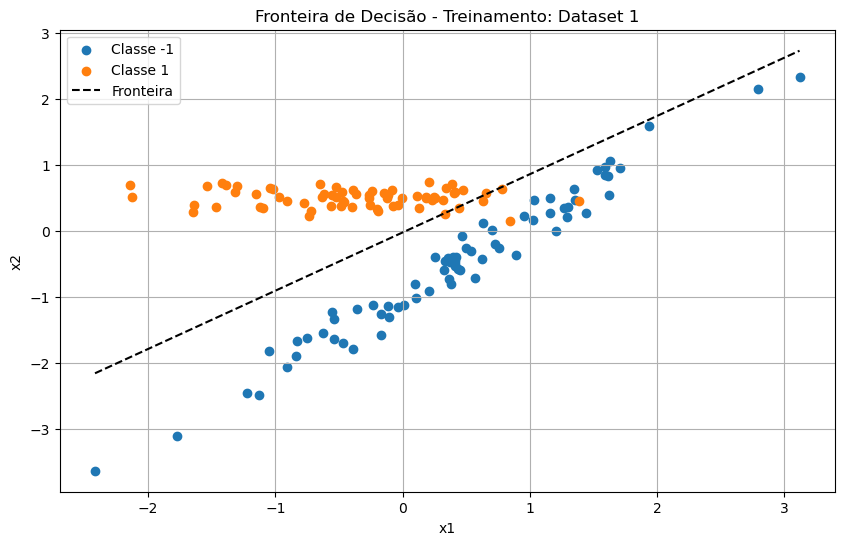

In [178]:
plot_decision_boundary(X_train1, y_train1, modelSGD, title='Fronteira de Decisão - Treinamento: Dataset 1')

##### Teste

In [179]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train1, y_train1))
print("Acurácia Teste:", modelSGD.accuracy(X_test1, y_test1))

Acurácia Treinamento: 0.9571428571428572
Acurácia Teste: 0.95


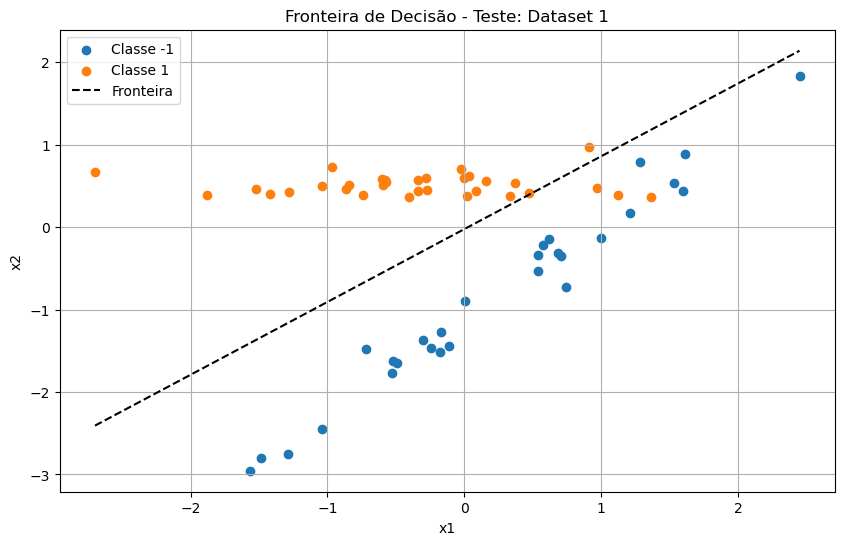

In [180]:
plot_decision_boundary(X_test1, y_test1, modelSGD, title='Fronteira de Decisão - Teste: Dataset 1')

#### Conclusões

1) Pode-se observar que o algoritmo está funcionando adequadamente. A partir dos resultados de treinamento e teste — especialmente ao analisar o gráfico da fronteira de decisão — verifica-se que o modelo Adaline é capaz de separar corretamente as classes, indicando um bom ajuste aos dados.

2) Além disso, nota-se uma alta acurácia na fase de treinamento, acompanhada por uma acurácia semelhante nos dados de teste. Esse comportamento indica que o modelo apresenta boa capacidade de generalização, sem evidências de overfitting.

3) Ao comparar as abordagens Batch (BGD) e estocástica (SGD), observa-se que ambas atingem níveis de acurácia semelhantes, como esperado, já que otimizam a mesma função de erro. No entanto, o SGD converge em um número menor de épocas, pois realiza atualizações mais frequentes nos pesos. Ainda assim, essa diferença deve ser analisada com cautela, uma vez que o custo computacional por época difere entre as abordagens.

4) Em relação à evolução do erro de classificação, observa-se que ambos os métodos apresentam uma queda acentuada nas primeiras épocas, indicando uma rápida aproximação a uma solução adequada. Posteriormente, o erro tende a estabilizar em valores próximos, evidenciando a eficiência de ambas as abordagens.

5) Por fim, embora o SGD tenha convergido em menos épocas, isso não implica necessariamente maior eficiência computacional global, uma vez que o custo por época difere do BGD. No entanto, em cenários com grandes volumes de dados, o SGD tende a ser mais vantajoso devido ao menor custo por atualização.

---

### Dataset 2

* Realizar o treinamento e teste para taxa de aprendizado 0.01, precisão de 0.001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

In [181]:
df_train2 = pd.read_csv('train_dataset2.csv')
X_train2 = df_train2.drop('label', axis=1).values.T
y_train2 = df_train2['label'].values.reshape(1, -1)

In [182]:
df_test2 = pd.read_csv('test_dataset2.csv')
X_test2 = df_test2.drop('label', axis=1).values.T
y_test2 = df_test2['label'].values.reshape(1, -1)

#### Batch Gradient Descent

##### Treinamento

In [183]:
modelBGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train2, y_train2)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train2, y_train2))

Pesos: [ 0.00497881 -0.00173592  0.0060212 ]
Épocas: 2
Acurácia: 0.5771428571428572


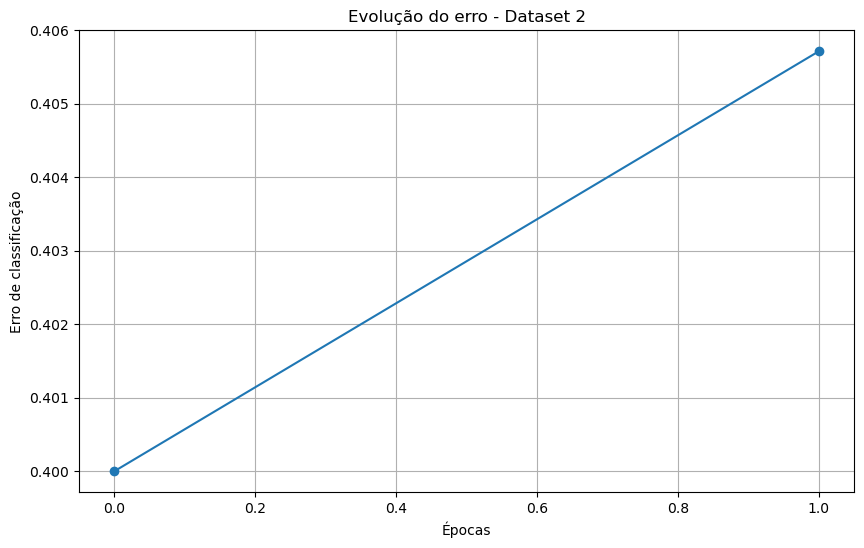

In [184]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 2")

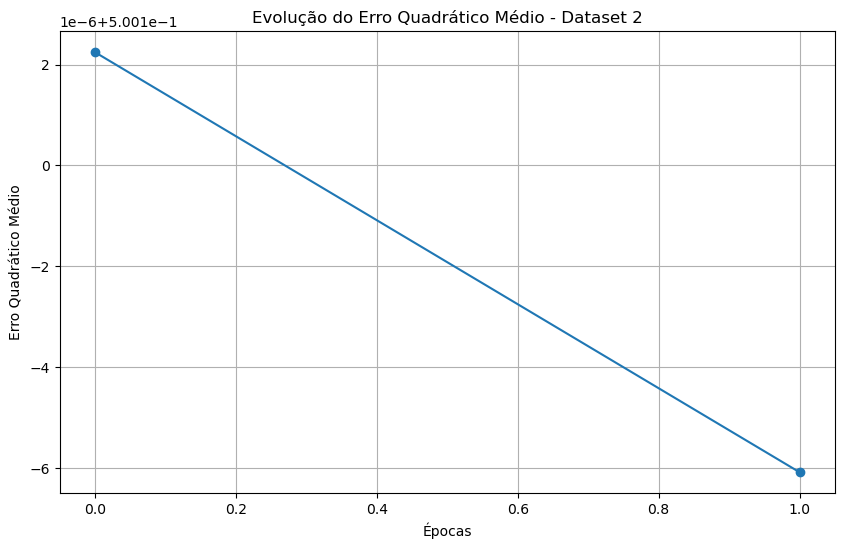

In [185]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 2")

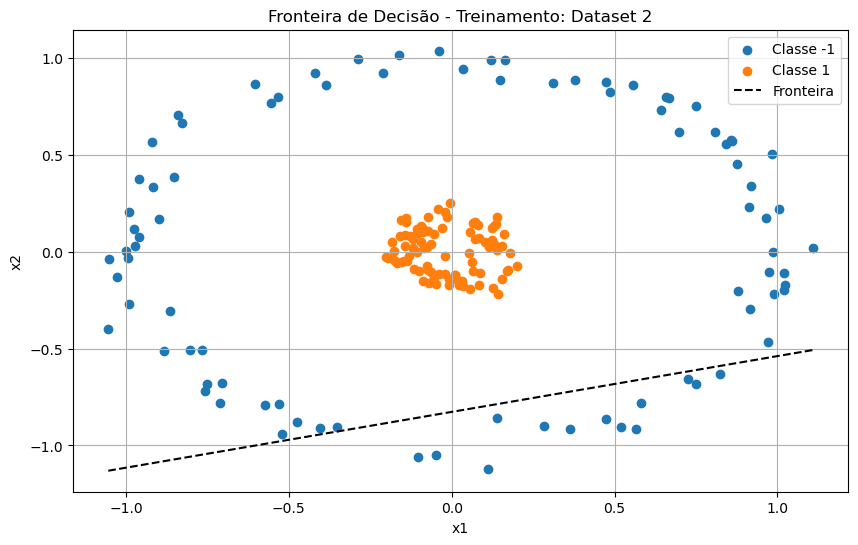

In [186]:
plot_decision_boundary(X_train2, y_train2, modelBGD, title='Fronteira de Decisão - Treinamento: Dataset 2')

##### Teste

In [187]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train2, y_train2))
print("Acurácia Teste:", modelBGD.accuracy(X_test2, y_test2))

Acurácia Treinamento: 0.5771428571428572
Acurácia Teste: 0.6666666666666666


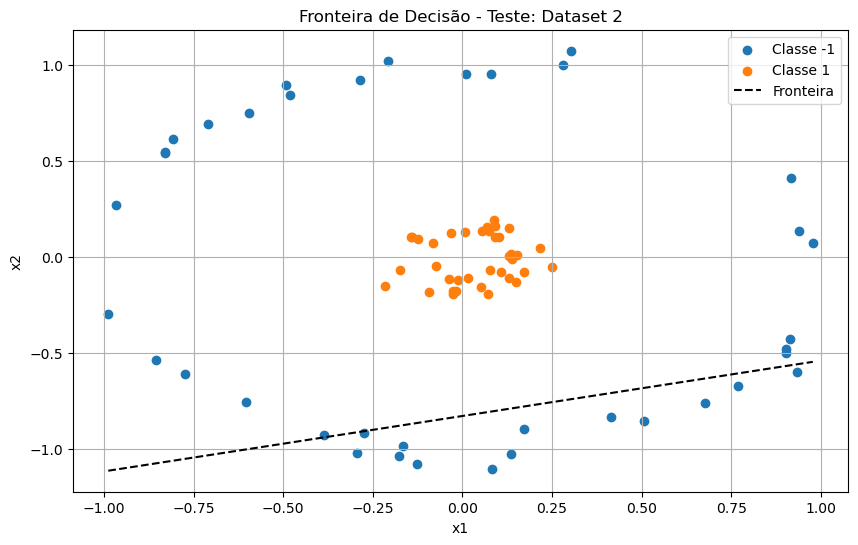

In [188]:
plot_decision_boundary(X_test2, y_test2, modelBGD, title='Fronteira de Decisão - Teste: Dataset 2')

#### Stochastic Gradient Descent

##### Treinamento

In [189]:
modelSGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train2, y_train2)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train2, y_train2))

Pesos: [-0.01670423 -0.03650577 -0.1211267 ]
Épocas: 7
Acurácia: 0.3657142857142857


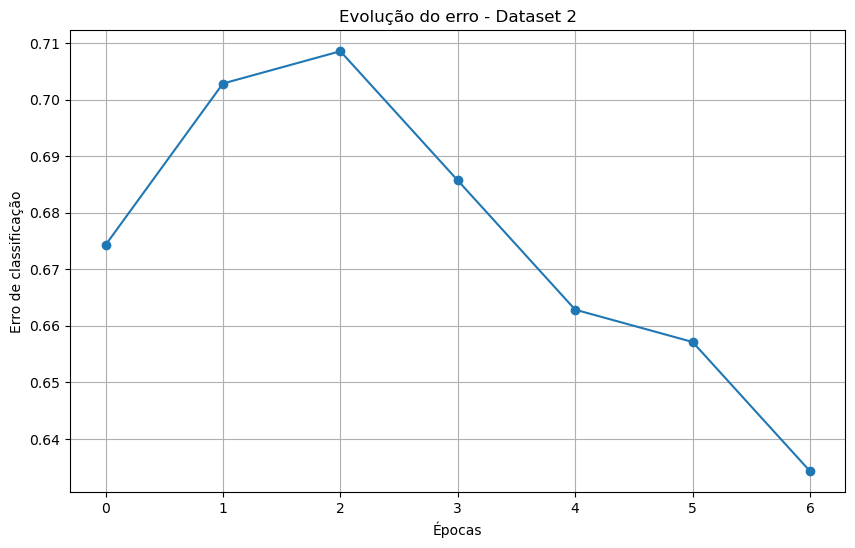

In [190]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 2")

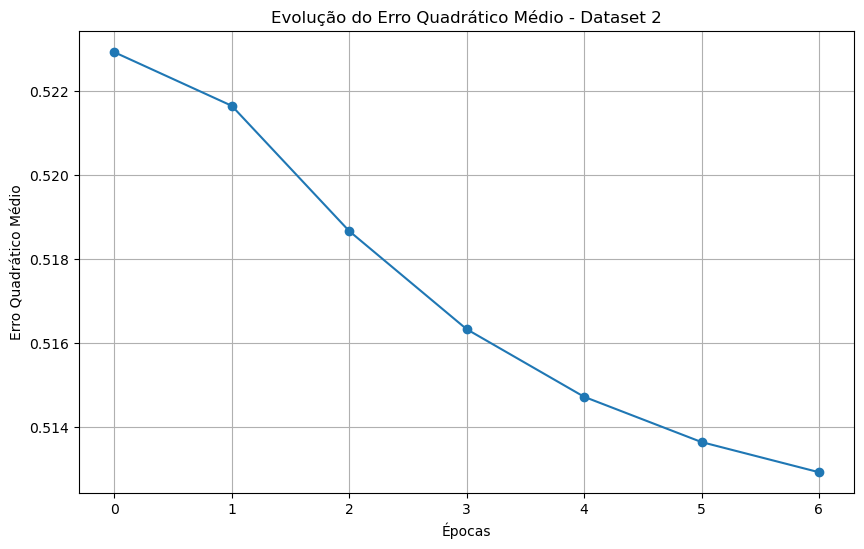

In [191]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 2")

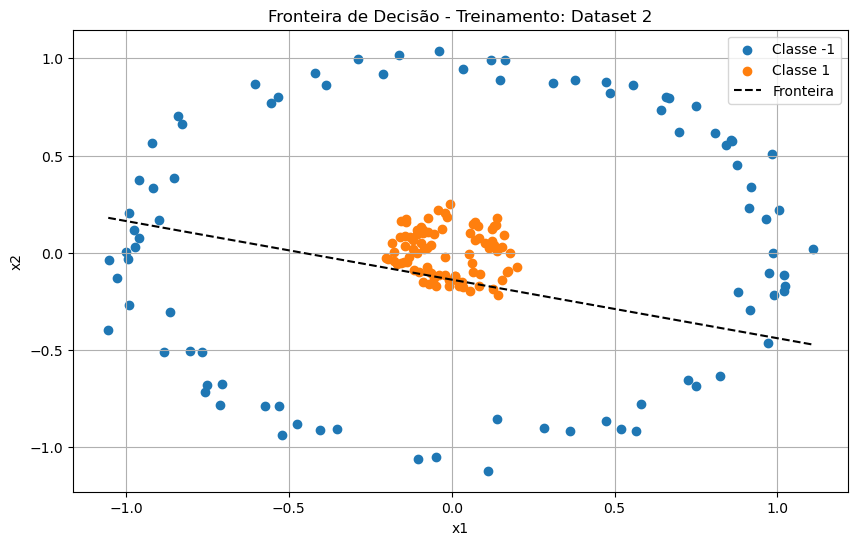

In [192]:
plot_decision_boundary(X_train2, y_train2, modelSGD, title='Fronteira de Decisão - Treinamento: Dataset 2')

##### Teste

In [193]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train2, y_train2))
print("Acurácia Teste:", modelSGD.accuracy(X_test2, y_test2))

Acurácia Treinamento: 0.3657142857142857
Acurácia Teste: 0.32


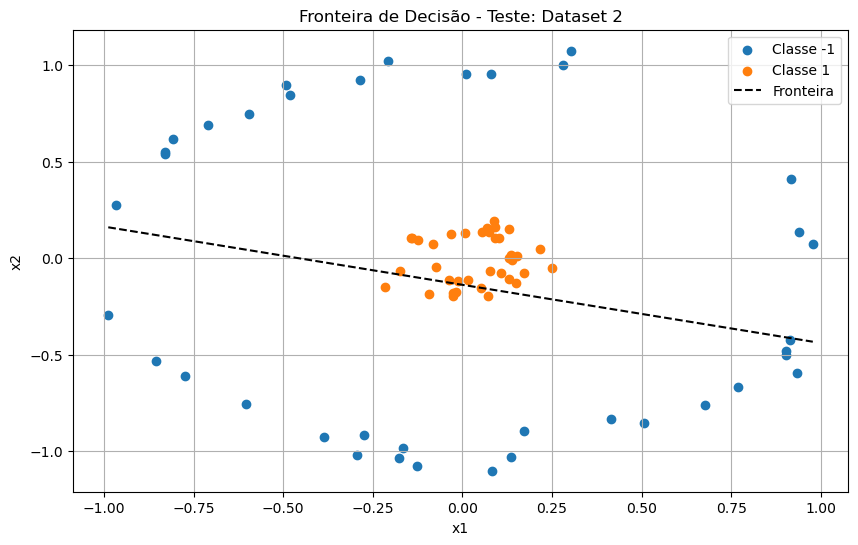

In [194]:
plot_decision_boundary(X_test2, y_test2, modelSGD, title='Fronteira de Decisão - Teste: Dataset 2')

#### Conclusões

1) Para este dataset, observa-se que o modelo não é capaz de aprender adequadamente a tarefa de classificação. Isso pode ser verificado tanto pela evolução do erro de classificação quanto pelo erro quadrático médio, que não apresentam uma convergência satisfatória.

2) Essa limitação do modelo torna-se ainda mais evidente ao analisar a acurácia obtida e, principalmente, ao observar o gráfico da fronteira de decisão, tanto para os dados de treinamento quanto de teste, nas duas abordagens (BGD e SGD). Nota-se que os dados do Dataset 2 não são linearmente separáveis, o que impede que o Adaline consiga estabelecer uma fronteira de decisão capaz de separar corretamente as classes, apesar de achar uma solução aproximada.

---

### Dataset 3

In [195]:
df_train3 = pd.read_csv('train_dataset3.csv')
X_train3 = df_train3.drop('label', axis=1).values.T
y_train3 = df_train3['label'].values.reshape(1, -1)

In [196]:
df_test3 = pd.read_csv('test_dataset3.csv')
X_test3 = df_test3.drop('label', axis=1).values.T
y_test3 = df_test3['label'].values.reshape(1, -1)

#### Experimento 1

* Realizar o treinamento e teste para taxa de aprendizado 0.01, precisão de 0.1 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

##### Batch Gradient Descent

##### Treinamento

In [197]:
modelBGD = Adaline(learning_rate=0.01, epochs=100, precision=0.1, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train3, y_train3)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train3, y_train3))

Pesos: [ 0.00383347 -0.00140478  0.00364834  0.01560717 -0.00337391 -0.00442329
  0.01759503  0.00749069 -0.00358488  0.00519719  0.01697649]
Épocas: 2
Acurácia: 0.7551020408163265


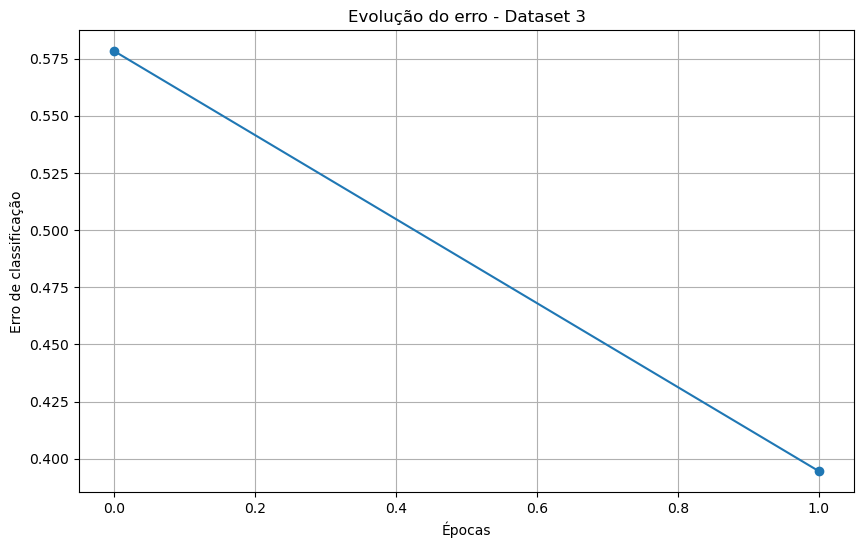

In [198]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 3")

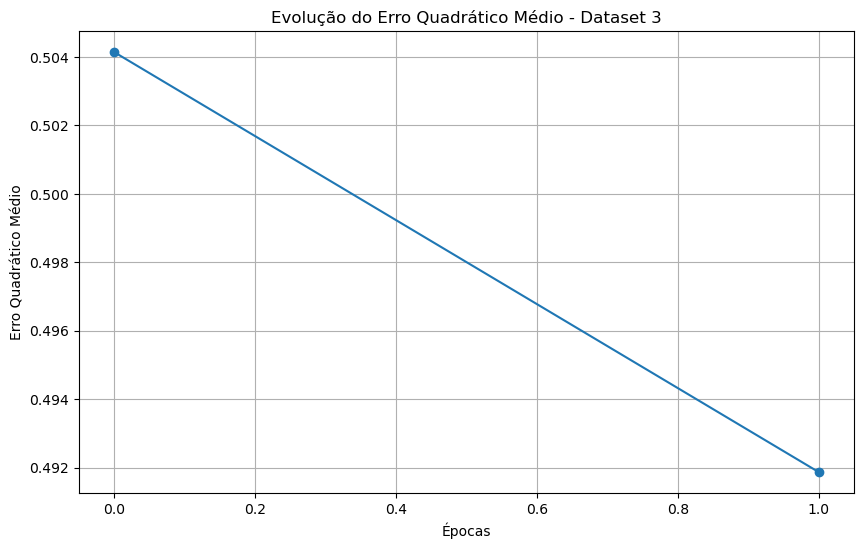

In [199]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [200]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelBGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.7551020408163265
Acurácia Teste: 0.6507936507936508


##### Stochastic Gradient Descent

##### Treinamento

In [201]:
modelSGD = Adaline(learning_rate=0.01, epochs=100, precision=0.1, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train3, y_train3)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train3, y_train3))

Pesos: [-0.01237955 -0.03819688 -0.05407556 -0.01720934 -0.02749893 -0.03433097
  0.02465473  0.0207893   0.05187667  0.00108593  0.60697171]
Épocas: 2
Acurácia: 0.9319727891156463


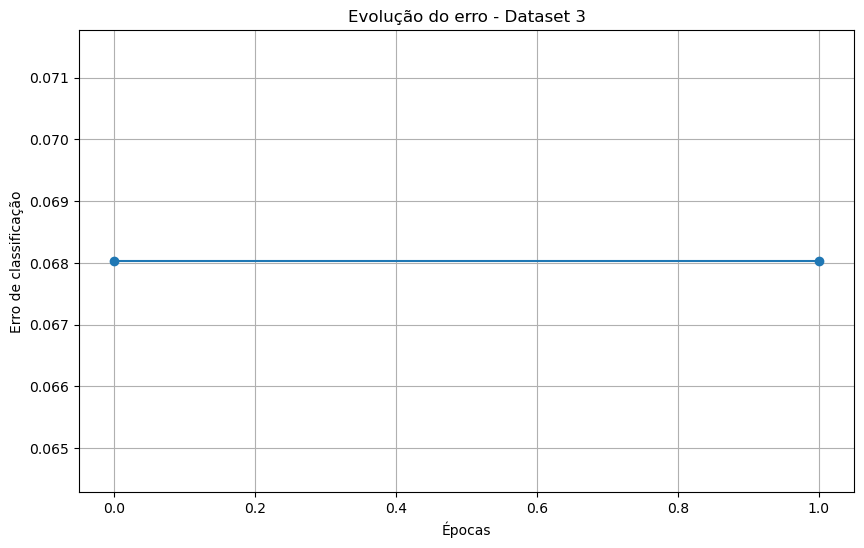

In [202]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 3")

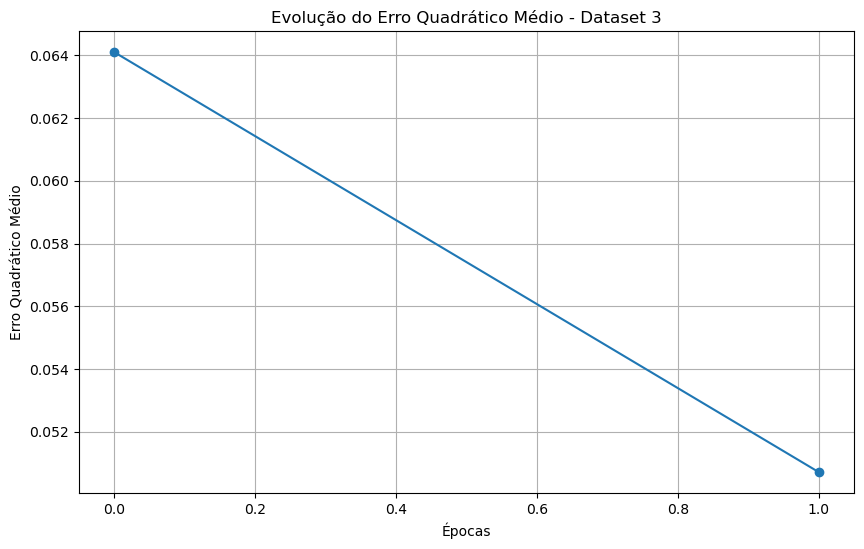

In [203]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [204]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelSGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9319727891156463
Acurácia Teste: 0.8571428571428571


##### Conclusão Experimento 1

1) Neste primeiro experimento, nota-se a capacidade do Algoritmo do Adaline em realizar teste com dataset que possuem uma maior quantidade de atributos. 

2) Em ambas abordagem, por Batch (BGD) e Stochastic (SGD), o modelo rodou apenas 2 épocas, resultado direto do alto valor para o critério de parada, mostrando que o modelo não conseguiu otimizar tão bem os parâmetros.

3) Quando comparadas as duas abordagens, nota-se uma melhor acurácia para a abordagem SGD, um resultado esperado considerando que a alta precisão fez com que tivessmos poucas épocas para a abordagem por Batch, isto é, neste caso a abordagem por amostra apresenta menos ruídos já que houve poucas amostras em poucas épocas.

---

#### Experimento 2

* Realizar o treinamento e teste para taxa de aprendizado 0.001, precisão de 0.1 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

##### Batch Gradient Descent

##### Treinamento

In [205]:
modelBGD = Adaline(learning_rate=0.001, epochs=100, precision=0.1, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train3, y_train3)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train3, y_train3))

Pesos: [ 0.00485229 -0.00138449  0.0061912   0.01526911 -0.0024459  -0.00255109
  0.01597484  0.00765552 -0.00458333  0.00540316 -0.00245521]
Épocas: 2
Acurácia: 0.46258503401360546


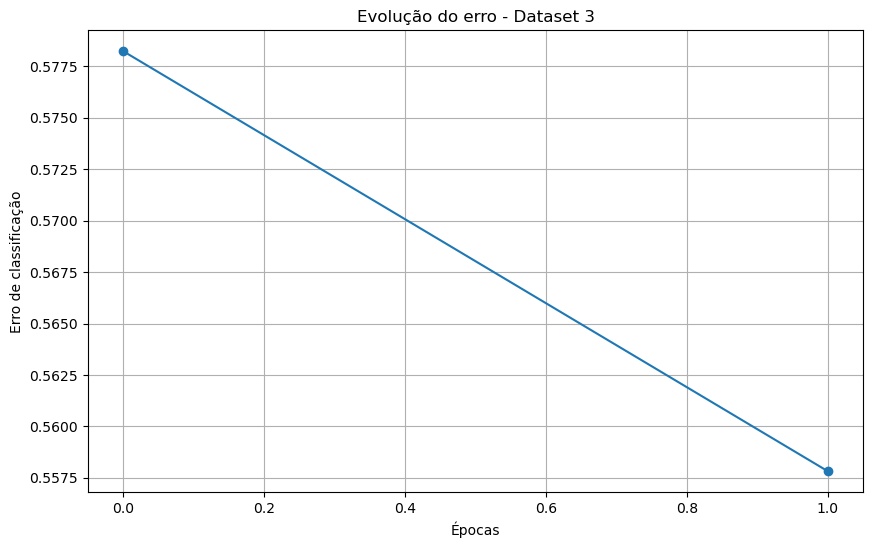

In [206]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 3")

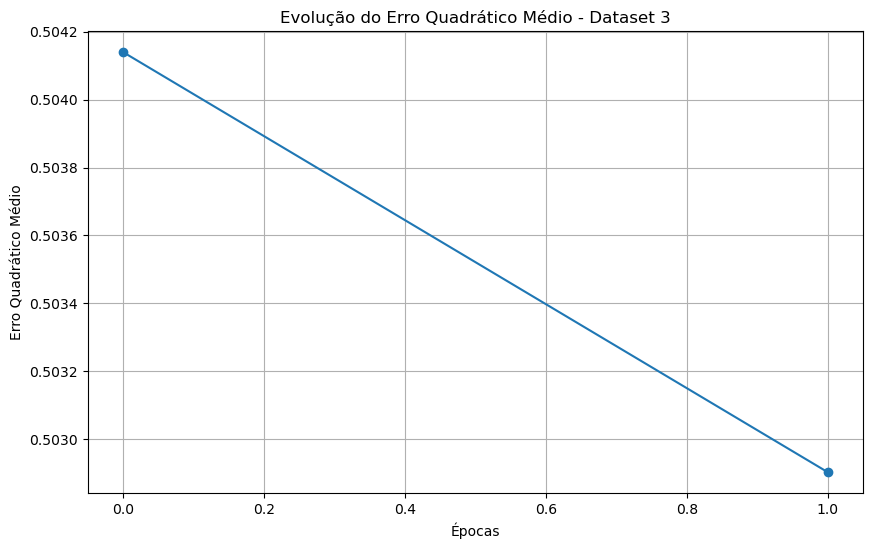

In [207]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [208]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelBGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.46258503401360546
Acurácia Teste: 0.38095238095238093


##### Stochastic Gradient Descent

##### Treinamento

In [209]:
modelSGD = Adaline(learning_rate=0.001, epochs=100, precision=0.1, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train3, y_train3)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train3, y_train3))

Pesos: [-0.00707535 -0.0028831  -0.02437511  0.01729498 -0.01324975 -0.02642906
  0.03399172  0.00609544  0.0096268   0.002509    0.24567441]
Épocas: 2
Acurácia: 0.9251700680272109


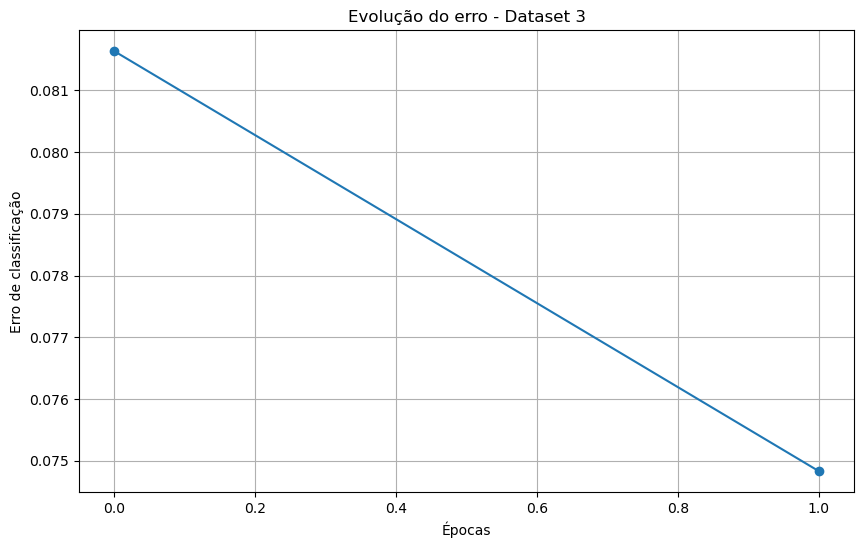

In [210]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 3")

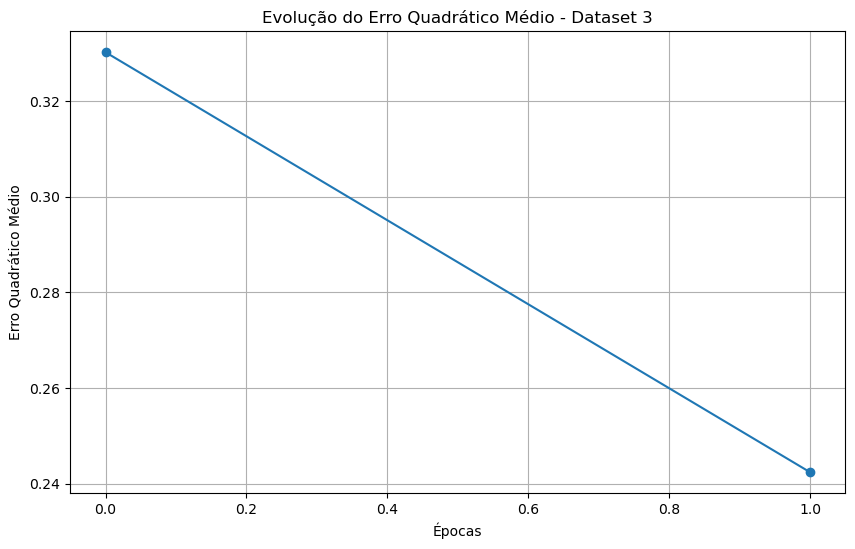

In [211]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [212]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelSGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9251700680272109
Acurácia Teste: 0.8253968253968254


##### Conclusão Experimento 2

1) Este experimento, mostra que diminuir a taxa de aprendizado mantendo a precisão para o critério de parada alto faz com que o modelo ainda persista em uma não otimização dos parâmetros. 

2) Novamente, apesar de não conseguir um bom desempenho, o modelo por abordagem Stochastic (SGD) apresentou uma acurácia maior.


---

#### Experimento 3

* Realizar o treinamento e teste para taxa de aprendizado 0.0001, precisão de 0.1 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

##### Batch Gradient Descent

##### Treinamento

In [213]:
modelBGD = Adaline(learning_rate=0.0001, epochs=100, precision=0.1, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train3, y_train3)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train3, y_train3))

Pesos: [ 0.00495564 -0.00138282  0.00644829  0.01523419 -0.00235198 -0.00236236
  0.01581042  0.00767246 -0.0046836   0.00542336 -0.0044161 ]
Épocas: 2
Acurácia: 0.4217687074829932


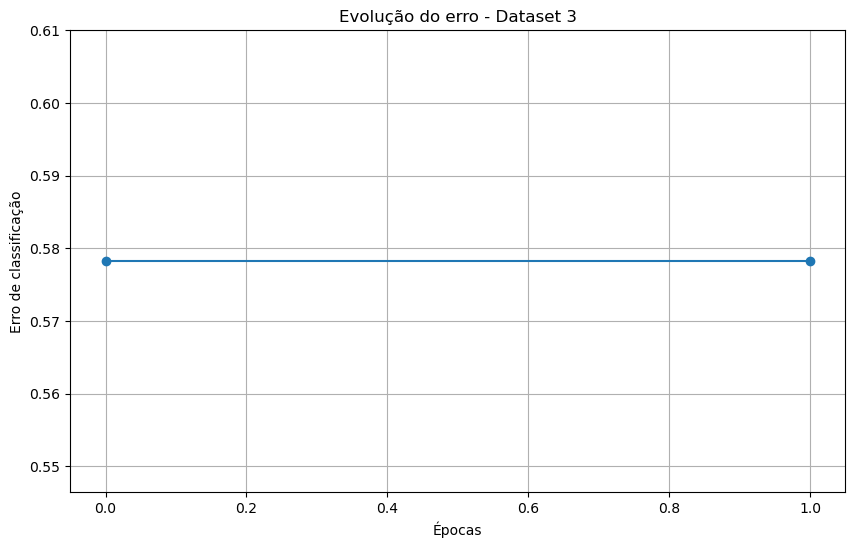

In [214]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 3")

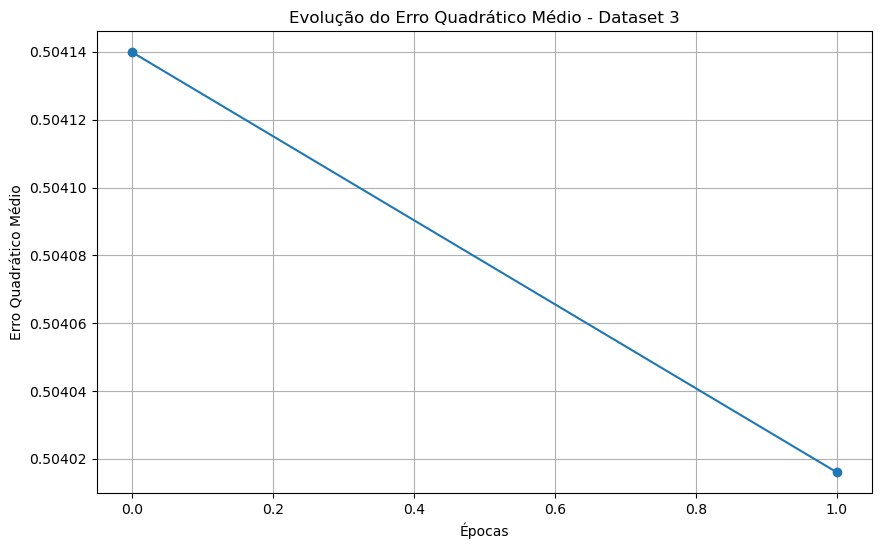

In [215]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [216]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelBGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.4217687074829932
Acurácia Teste: 0.3333333333333333


##### Stochastic Gradient Descent

##### Treinamento

In [217]:
modelSGD = Adaline(learning_rate=0.0001, epochs=100, precision=0.1, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train3, y_train3)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train3, y_train3))

Pesos: [ 0.00333365 -0.00142333  0.00240506  0.01575796 -0.00382351 -0.00535019
  0.01837863  0.00741001 -0.00307867  0.00510009  0.02661225]
Épocas: 2
Acurácia: 0.8027210884353742


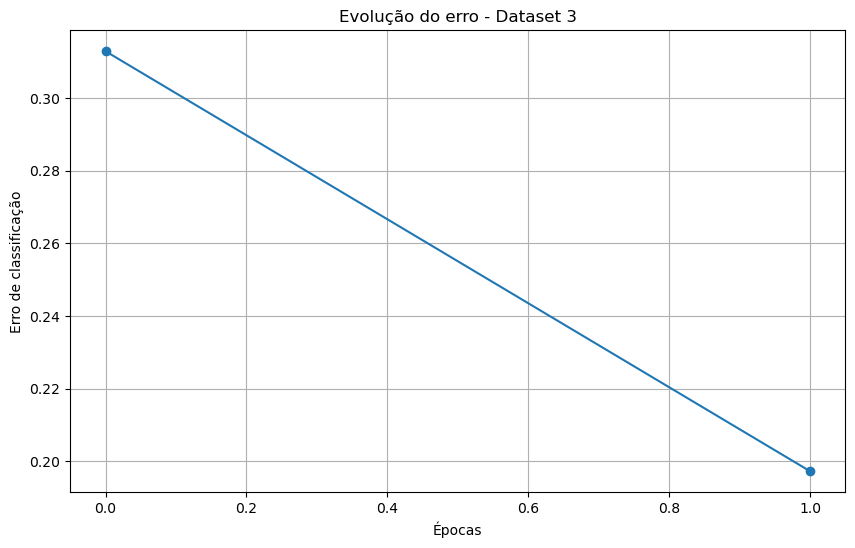

In [218]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 3")

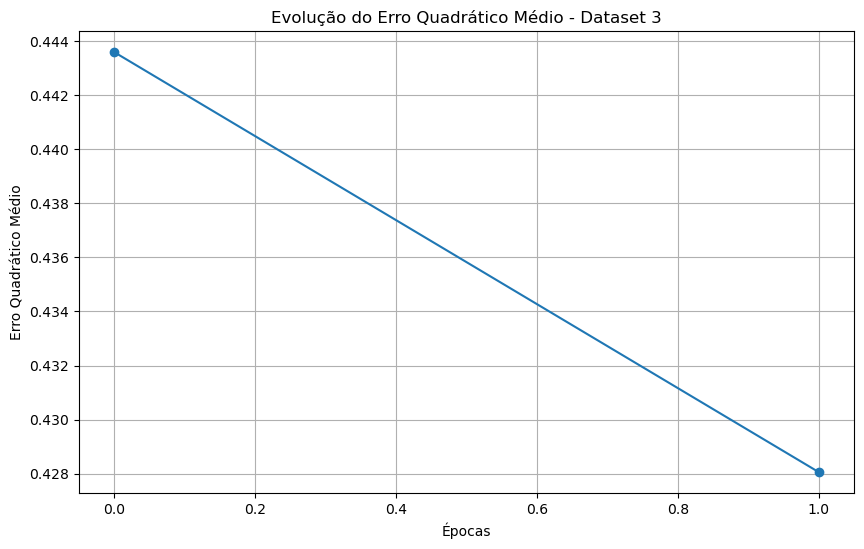

In [219]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [220]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelSGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.8027210884353742
Acurácia Teste: 0.7301587301587301


##### Conclusão Experimento 3

1) Nota-se uma piora ainda maior comparando estes resultados com os resultados do Experimento 2. Essa piora é resultado da diminuição da taxa de aprendizado, o qual poderíamos esperar uma melhora, entretanto, para uma alta precisão em comparação à taxa de aprendizado $\varepsilon$, o modelo não consegue aprender adequadamente para otimizar os parâmetros e, portanto, não classifica corretamente. 

---

#### Experimento 4

* Realizar o treinamento e teste para taxa de aprendizado 0.01, precisão de 0.0001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

##### Batch Gradient Descent

##### Treinamento

In [221]:
modelBGD = Adaline(learning_rate=0.01, epochs=100, precision=0.0001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train3, y_train3)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train3, y_train3))

Pesos: [-0.00817409 -0.00986865 -0.04782844  0.00589994 -0.02055556 -0.05391204
  0.03568041  0.01102692  0.03297468 -0.01114195  0.50124627]
Épocas: 100
Acurácia: 0.9319727891156463


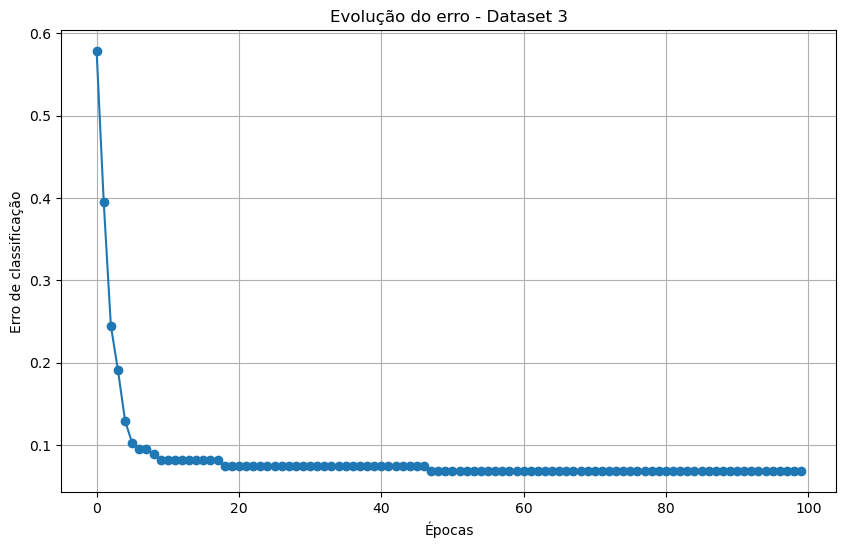

In [222]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 3")

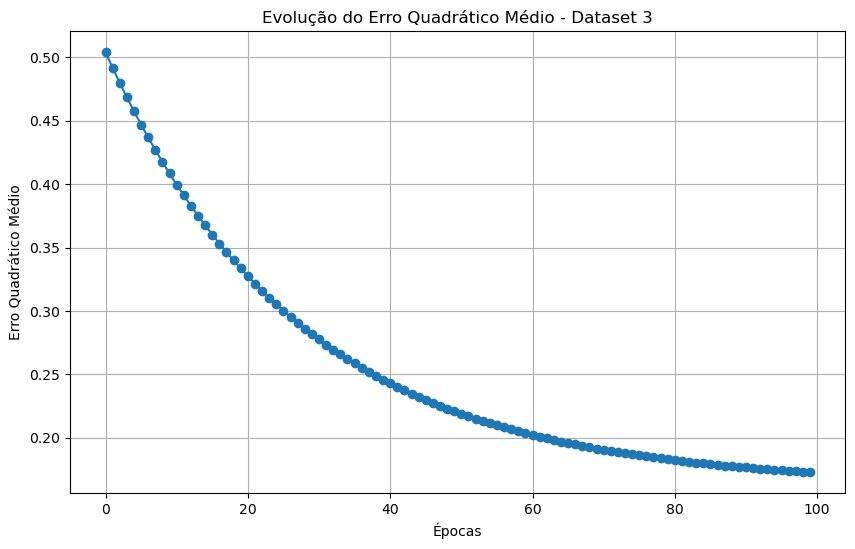

In [223]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [224]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelBGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9319727891156463
Acurácia Teste: 0.8571428571428571


##### Stochastic Gradient Descent

##### Treinamento

In [225]:
modelSGD = Adaline(learning_rate=0.01, epochs=100, precision=0.0001, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train3, y_train3)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train3, y_train3))

Pesos: [-4.97748772e-03 -3.96772173e-02 -5.28312517e-02 -2.54081655e-02
 -2.89037358e-02 -2.87455598e-02  1.48000723e-02  2.60180336e-02
  5.81716414e-02 -5.30414110e-04  6.11844712e-01]
Épocas: 5
Acurácia: 0.9387755102040817


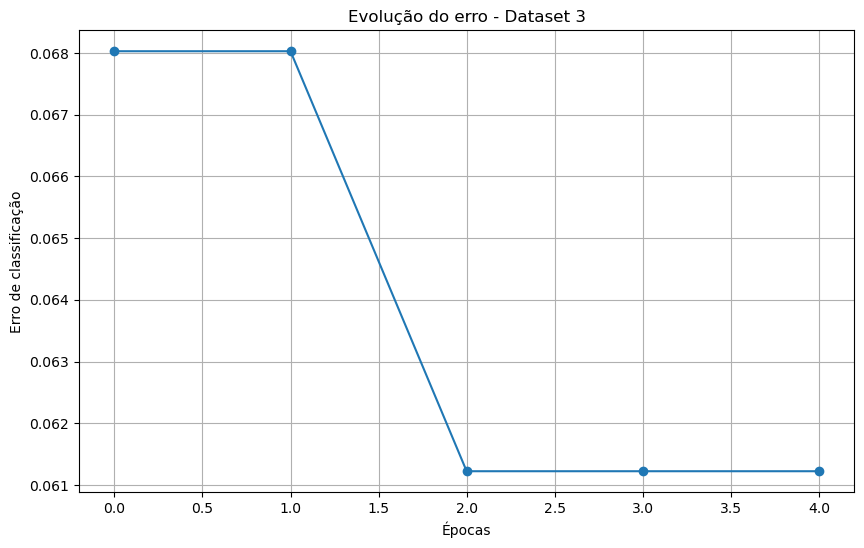

In [226]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 3")

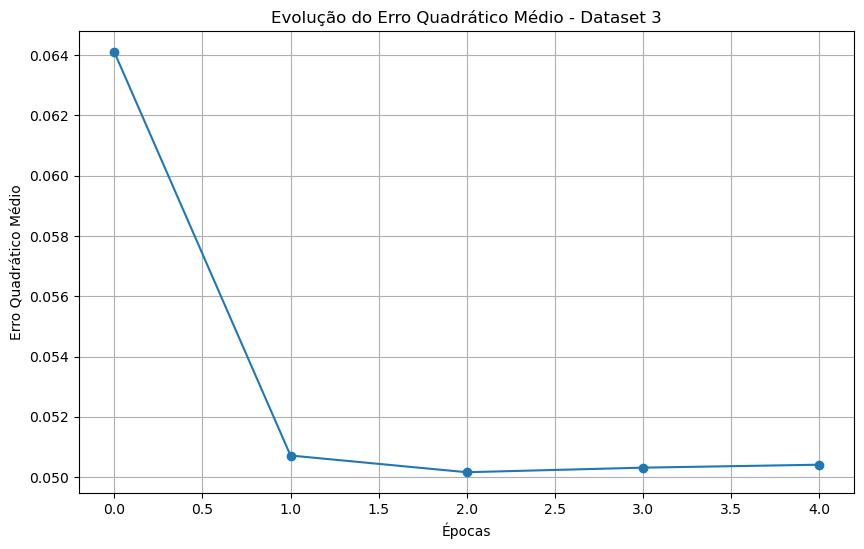

In [227]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [228]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelSGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9387755102040817
Acurácia Teste: 0.8571428571428571


##### Conclusão Experimento 4

1) Neste experimento, observa-se uma melhora significativa no desempenho do modelo ao reduzir o parâmetro de precisão para $\varepsilon=0.0001$, o que favorece uma convergência mais refinada dos resultados.

2) Na abordagem Batch (BGD), o modelo apresentou alta acurácia tanto no treinamento quanto no teste, sem indícios de overfitting. Além disso, nota-se uma evolução suave do erro quadrático médio ao longo das 100 épocas, indicando um processo de otimização estável.

3) Por sua vez, a abordagem estocástica (SGD) também se mostrou bastante eficiente, alcançando valores de acurácia muito próximos aos obtidos com o BGD. No entanto, o SGD atingiu esses resultados em um número significativamente menor de épocas (apenas 5), o que evidencia o menor custo de poder computacional.


---

#### Experimento 5

* Realizar o treinamento e teste para taxa de aprendizado 0.001, precisão de 0.0001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

##### Batch Gradient Descent

##### Treinamento

In [229]:
modelBGD = Adaline(learning_rate=0.001, epochs=100, precision=0.0001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train3, y_train3)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train3, y_train3))

Pesos: [-2.27521018e-05 -1.65303749e-03 -6.36367012e-03  1.66096205e-02
 -6.98770441e-03 -1.20376608e-02  2.36971562e-02  6.96653515e-03
  6.49098944e-04  4.11291663e-03  9.51380014e-02]
Épocas: 100
Acurácia: 0.9183673469387755


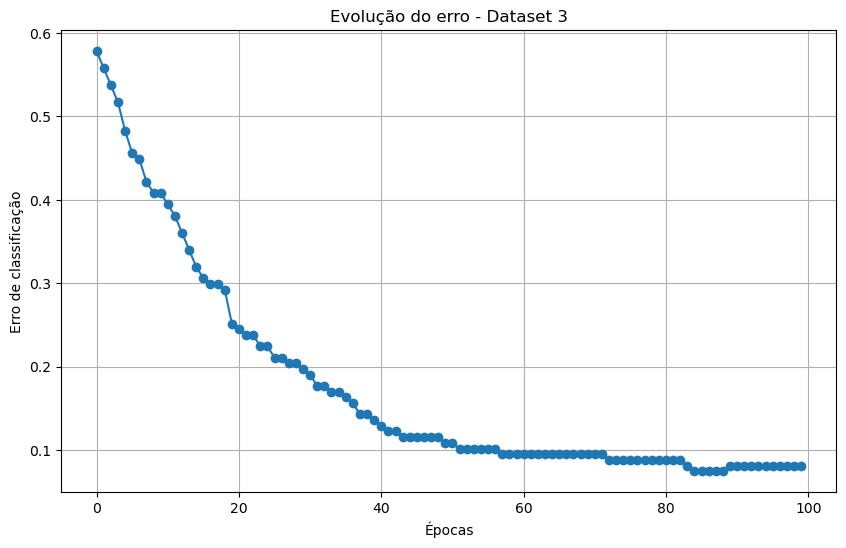

In [230]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 3")

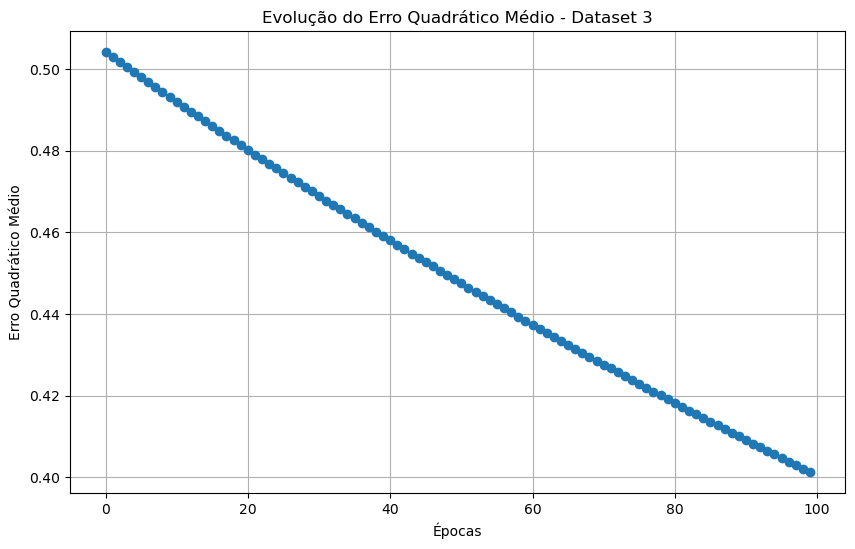

In [231]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [232]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelBGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9183673469387755
Acurácia Teste: 0.8253968253968254


##### Stochastic Gradient Descent

##### Treinamento

In [233]:
modelSGD = Adaline(learning_rate=0.001, epochs=100, precision=0.0001, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train3, y_train3)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train3, y_train3))

Pesos: [ 0.0080384  -0.02024532 -0.04349129 -0.01752775 -0.01907973 -0.05896251
  0.00937256  0.02318812  0.05765076 -0.02008501  0.60666043]
Épocas: 22
Acurácia: 0.9387755102040817


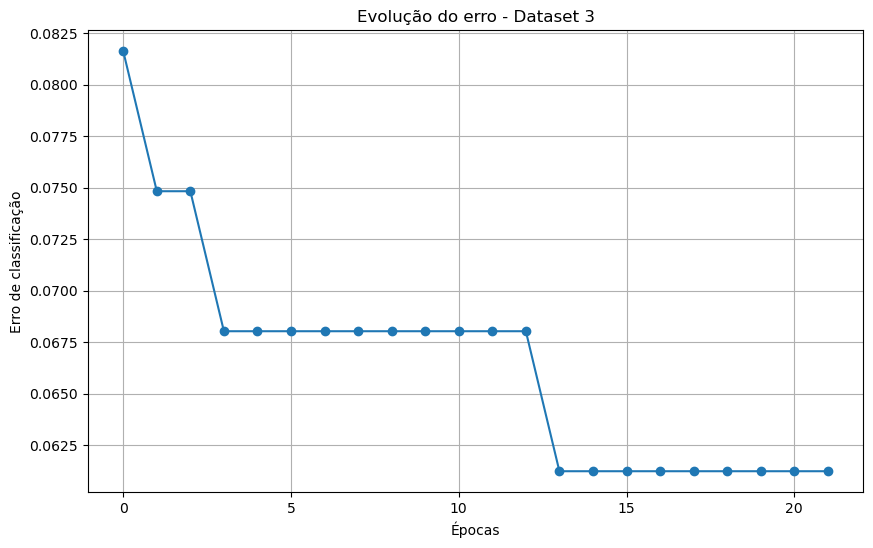

In [234]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 3")

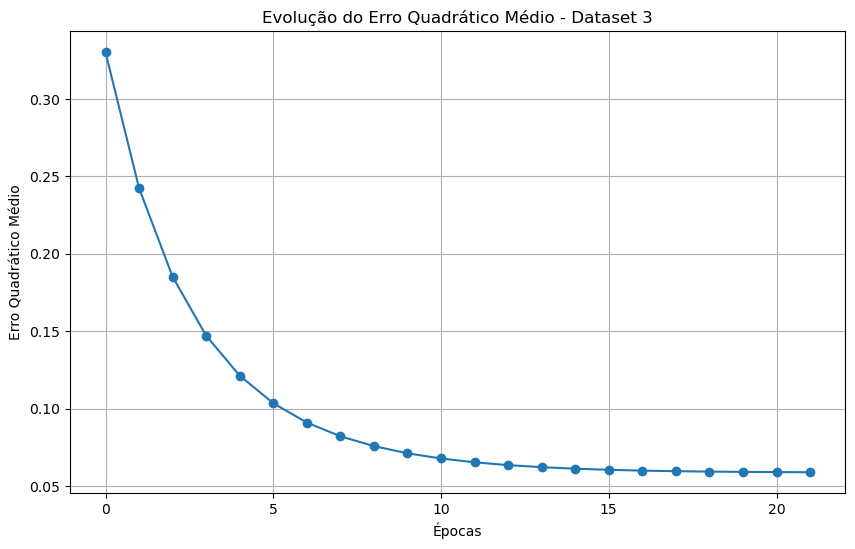

In [235]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [236]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelSGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9387755102040817
Acurácia Teste: 0.873015873015873


##### Conclusão Experimento 5

1) Observa-se uma piora nos resultados deste experimento quando comparados à abordagem Batch (BGD) do Experimento 4. Esse comportamento indesejado pode ser atribuído à proximidade entre a taxa de aprendizado e o valor da precisão, o que prejudica a qualidade da otimização. Como consequência, o processo de minimização torna-se menos suave, dificultando o ajuste adequado dos parâmetros. Nota-se que, embora o erro de classificação do BGD atinja valores semelhantes aos do Experimento 4, a acurácia do modelo apresentou queda.

2) Em contrapartida, a abordagem por amostra (SGD) apresentou melhor desempenho neste cenário, alcançando maior acurácia nos dados de teste. Além disso, observa-se uma evolução mais suave do erro quadrático médio, indicando um processo de otimização mais eficiente para este dataset utilizando SGD.

---

#### Experimento 6

* Realizar o treinamento e teste para taxa de aprendizado 0.0001, precisão de 0.0001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

##### Batch Gradient Descent

##### Treinamento

In [237]:
modelBGD = Adaline(learning_rate=0.0001, epochs=100, precision=0.0001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train3, y_train3)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train3, y_train3))

Pesos: [ 0.00440017 -0.00139367  0.00506236  0.01541885 -0.00285783 -0.00338246
  0.01669381  0.00758247 -0.00413978  0.00531145  0.00617274]
Épocas: 100
Acurácia: 0.6054421768707483


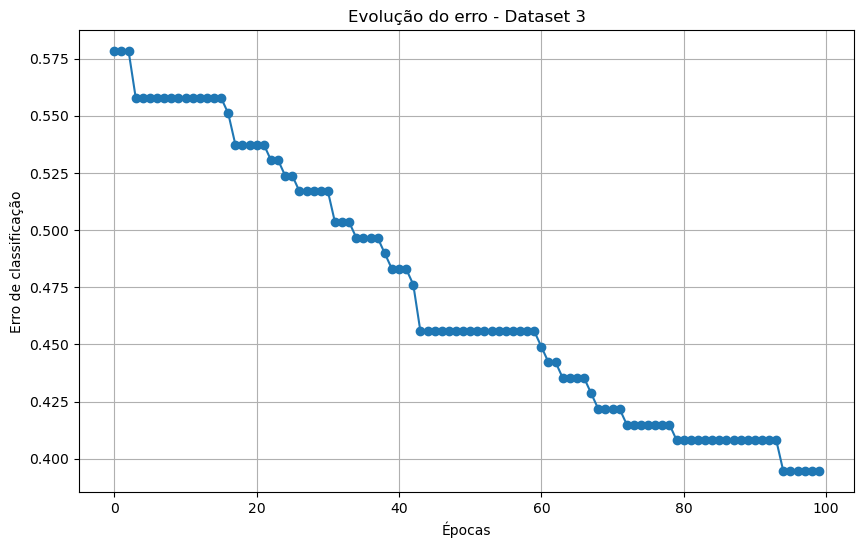

In [238]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 3")

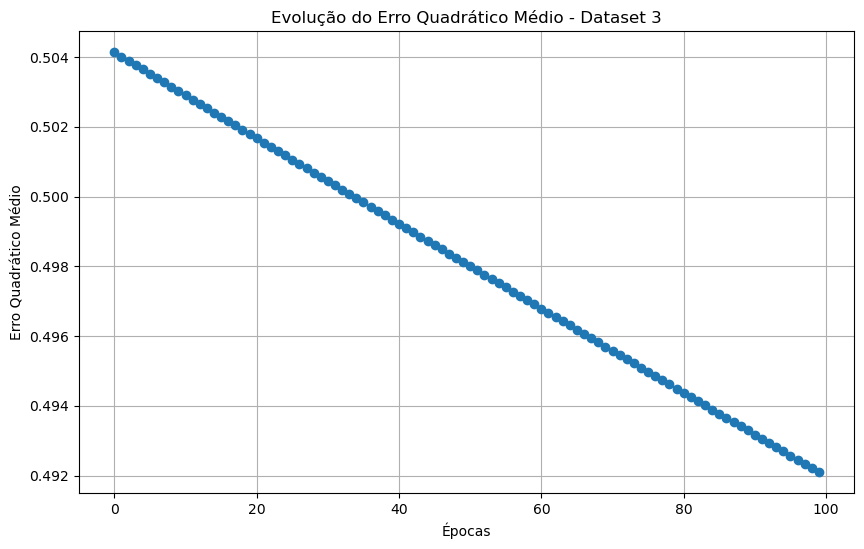

In [239]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [240]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelBGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.6054421768707483
Acurácia Teste: 0.5238095238095238


##### Stochastic Gradient Descent

##### Treinamento

In [241]:
modelSGD = Adaline(learning_rate=0.0001, epochs=100, precision=0.0001, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train3, y_train3)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train3, y_train3))

Pesos: [-0.0038126  -0.01360846 -0.04884094 -0.00213692 -0.0204506  -0.05953796
  0.02849441  0.01474521  0.04223319 -0.01604291  0.55828006]
Épocas: 100
Acurácia: 0.9319727891156463


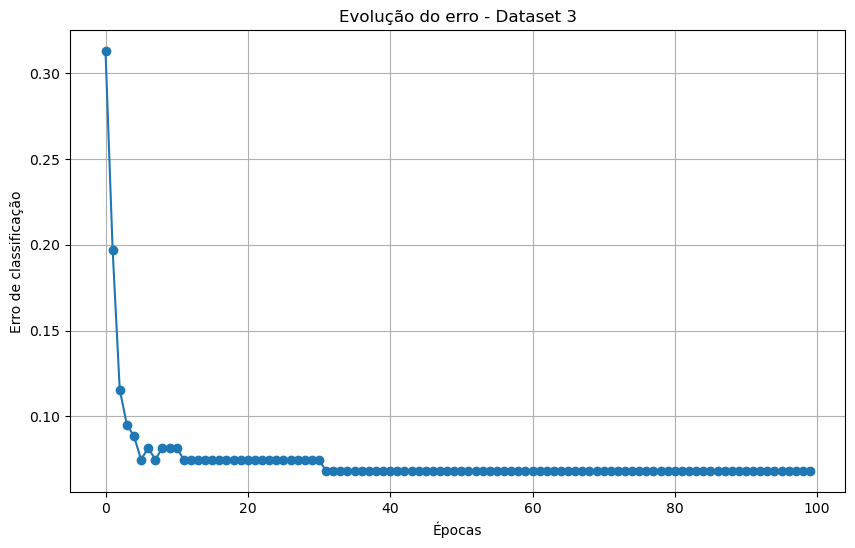

In [242]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 3")

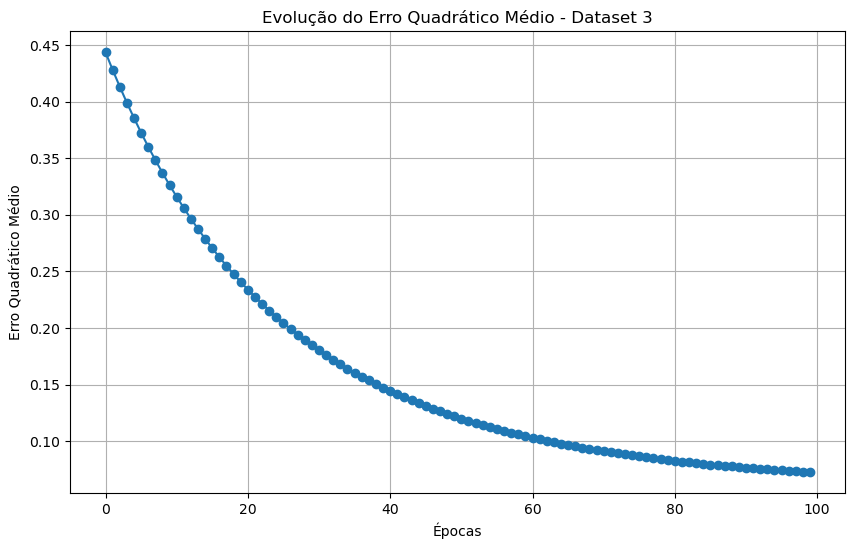

In [243]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 3")

##### Teste

In [244]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train3, y_train3))
print("Acurácia Teste:", modelSGD.accuracy(X_test3, y_test3))

Acurácia Treinamento: 0.9319727891156463
Acurácia Teste: 0.873015873015873


##### Conclusão Experimento 6

1) Neste caso, observa-se que, ao igualar a taxa de aprendizado ao valor da precisão do critério de parada, a abordagem Batch (BGD) apresentou uma piora no desempenho. Houve redução nos valores de acurácia, além da convergência para níveis mais elevados tanto do erro de classificação quanto do erro quadrático médio. Esse comportamento é esperado, pois a proximidade entre esses hiperparâmetros pode comprometer o processo de otimização, tornando-o menos eficiente e dificultando a convergência adequada dos parâmetros do modelo.

2) Por outro lado, conforme observado no Experimento 4, a redução da taxa de aprendizado favorece uma convergência mais suave na abordagem estocástica (SGD). Isso resulta em uma melhor estabilização dos erros e em valores de acurácia semelhantes aos obtidos anteriormente, indicando que, neste cenário, o SGD se mostra mais robusto e eficaz do que o BGD.


---

--- 

#### Conclusões Gerais

**Dataset 1:** O experimentou mostrou a eficiência do modelo como classificador linear para dados linearmente separáveis, mostrando principalmente a redução do custo computacional quando comparadas as abordagens por amostra e por batch.

**Dataset 2:** O experimentou mostrou a ineficacia do modelo para classificar datasets não linearmente separáveis, resultado da limitação do modelo. 

**Dataset 3:** Os experimentos mostraram que uma alta precisão para o critério de parada faz com que o algoritmo pare cedo demais, tornando a otimização ineficiente. Entretanto, refinar o critério de parada faz com que o modelo realize uma otimização e minimização mais suaves, garantindo uma melhor classificação de dados robustos, como o dataset 3 com 10 atributos. Nota-se também à partir dos experimentos que a abordagem por amostra (SGD) para dados maiores e mais complexos é mais eficaz quando comparado à abordagem por batch (BGD).